<a href="https://colab.research.google.com/github/mariajosemuskusl/Integracion-de-Datos-y-Prospectiva/blob/main/Reto_4_Riesgo_Operacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Reto 4**

**Evaluación del Riesgo Operacional en Canales Electrónicos | FINTECH**


---
María José Muskus Londoño



**Contexto del caso**

Se analiza un caso de riesgo operacional en una entidad financiera. Como analistas de riesgos, se cuenta con una base de datos histórica de eventos asociados a fallas tecnológicas ocurridas en los canales electrónicos, específicamente en la App móvil, la sucursal virtual y los cajeros automáticos.

Estos eventos reflejan situaciones reales donde errores tecnológicos afectan la operación normal del banco, generando pérdidas económicas y afectando la experiencia del cliente.

**Objetivo**

El objetivo principal es transformar estos datos en una herramienta de apoyo para la toma de decisiones.Cuantificar la exposición económica al riesgo operacional y evaluar qué tan efectivos son los controles actuales en la reducción de ese riesgo.

**Metodología**

Se construye una arquitectura de matrices que permite organizar la información desde diferentes perspectivas:

- **Matriz de Frecuencia:** mide cuántas veces ocurren los eventos.
- **Matriz de Severidad:** clasifica el impacto económico de cada evento.
- **Matriz de Pérdidas Agregadas:** combina frecuencia y severidad para estimar la exposición total.
- **Matriz de Impacto y Gestión:** permite evaluar el riesgo antes y después de aplicar controles.

Adicionalmente, se realiza una estimación cuantitativa del riesgo mediante:

- El cálculo de la Pérdida Esperada (PE).
- La estimación del Operational Value at Risk (OpVaR) al 99,9%, que permite medir pérdidas extremas.

Finalmente, se desarrolla una herramienta de auditoría (filtro dinámico) que permite analizar en detalle los eventos que componen cada celda de las matrices.

**Variables**

- **Fecha:** día en que ocurrió la falla tecnológica.
- **Transacciones_Diarias:** volumen total de transacciones procesadas ese día.
- **Valor_Transado_MM:** valor total transado en millones de USD.
- **Frecuencia:** número de transacciones fallidas en el evento.
- **Severidad:** pérdida económica asociada a la falla (en MM USD).
- **Descripcion_Evento:** descripción del tipo de falla ocurrida.


**0. Cargar librerías de trabajo**

In [1]:
# 0. Cargamos las librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Cargar la base de datos**

In [2]:
nxl = '/content/drive/MyDrive/University/Integración de Datos y Prospectiva/Retos/Reto 4/5. Riesgo Operacional FallasTecnológicas.xlsx'

XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas', header=1)

XDB.columns = [
    'Fecha',
    'Transacciones_Diarias',
    'Valor_Transado_MM',
    'Frecuencia',
    'Severidad',
    'Descripcion_Evento'
]

XDB.head()

,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad,Descripcion_Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [3]:
# Revisamos información general de la base de datos

print("Número de registros:", len(XDB))
print("Columnas:", XDB.columns.tolist())

XDB.describe()

Número de registros: 701
Columnas: ['Fecha', 'Transacciones_Diarias', 'Valor_Transado_MM', 'Frecuencia', 'Severidad', 'Descripcion_Evento']


,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad
count,701,701.000000,701.000000,701.000000,701.000000
mean,2010-06-25 06:30:17.974322176,99.158345,24.248679,4.753210,1.929555
min,2009-01-01 00:00:00,35.000000,-9.957400,1.000000,0.084200
25%,2009-06-25 00:00:00,85.000000,16.851100,2.000000,0.631300
50%,2011-01-01 00:00:00,100.000000,24.162000,4.000000,1.224000
75%,2011-06-25 00:00:00,115.000000,31.537300,7.000000,2.343900
max,2011-12-17 00:00:00,170.000000,59.566900,16.000000,17.312900
std,NaN,22.081130,11.598671,2.984796,2.130130


**2. Función de clusterización para clasificar frecuencia y severidad**

In [4]:
def clusterizacion(Xi):

  XC = np.random.choice(Xi, size=5)
  XC = np.sort(XC)
  nc = np.zeros(len(Xi))

  for k in range(len(Xi)):
    d = np.abs(XC - Xi[k])
    nc[k] = np.argmin(d)
    nc2 = np.int32(nc[k])
    XC[nc2] = (XC[nc2] + Xi[k]) / 2

  return XC, nc

In [5]:
# Variables principales

np.random.seed(42)

Xf = np.array(XDB['Frecuencia'])
Xs = np.abs(np.array(XDB['Severidad']))

XCf, ncf = clusterizacion(Xf)
XCs, ncs = clusterizacion(Xs)

LDA = Xf * Xs
XClda, nclda = clusterizacion(LDA)

df = pd.DataFrame({
    'Fecha': XDB['Fecha'],
    'Frecuencia': Xf,
    'Nivel_f': ncf.astype(int),
    'Severidad': Xs,
    'Nivel_s': ncs.astype(int),
    'LDA': LDA,
    'Nivel_LDA': nclda.astype(int),
    'Descripcion_Evento': XDB['Descripcion_Evento']
})

df.head()

,Fecha,Frecuencia,Nivel_f,Severidad,Nivel_s,LDA,Nivel_LDA,Descripcion_Evento
0,2009-01-01,1,0,0.5374,0,0.5374,0,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,4,0,1.1978,2,4.7912,2,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,5,1,0.4269,0,2.1345,1,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,6,1,1.0814,1,6.4884,3,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,7,2,1.2105,2,8.4735,4,"Errores en la interfaz de usuario, fallas en f..."


**3. Matriz de frecuencia y severidad**

In [17]:
# Matriz de frecuencia y matriz de severidad

MEf = np.zeros((5,5))
MEs = np.zeros((5,5))

for k in range(len(Xf)):
    nf = np.int32(ncf[k])
    ns = np.int32(ncs[k])

    MEf[nf, ns] = MEf[nf, ns] + Xf[k]
    MEs[nf, ns] = (MEs[nf, ns] + Xs[k]) / 2

MLDA = MEf * MEs

print("Pérdida agregada total:", round(MLDA.sum(), 4), "MM USD")

Pérdida agregada total: 7247.4869 MM USD


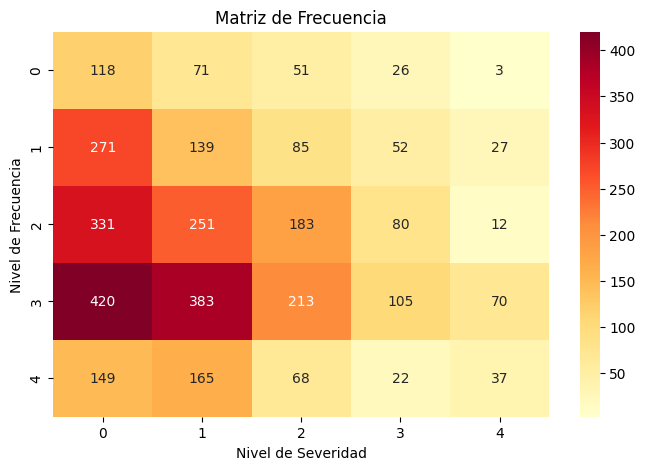

In [18]:
# Matriz de frecuencia

plt.figure(figsize=(8,5))
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Matriz de Frecuencia')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

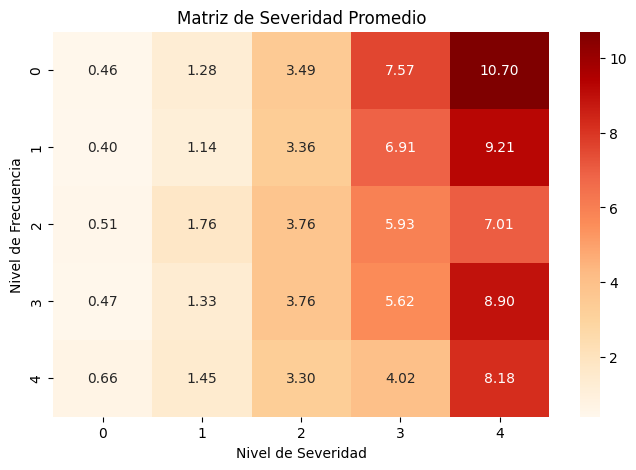

In [19]:
# Matriz de severidad

plt.figure(figsize=(8,5))
sns.heatmap(MEs, annot=True, fmt='.2f', cmap='OrRd')
plt.title('Matriz de Severidad Promedio')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

**4. Matriz de pérdidas agregadas, de impacto y de gestión**

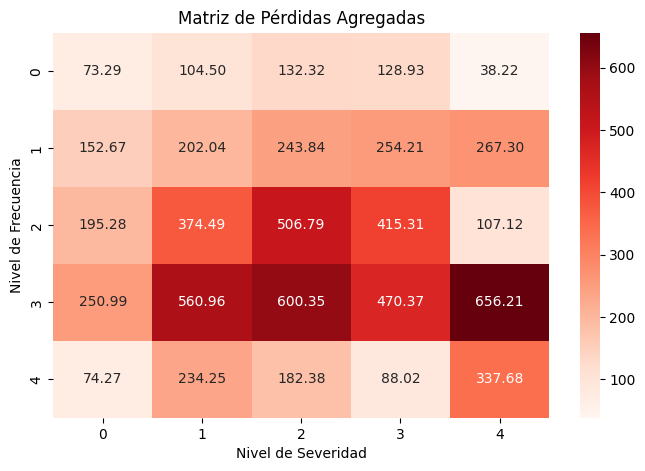

Pérdida agregada total: 6651.79 MM USD


In [9]:
# Matriz de pérdidas agregadas

MLDA = MEf * MEs

plt.figure(figsize=(8,5))
sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='Reds')
plt.title('Matriz de Pérdidas Agregadas')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

print("Pérdida agregada total:", round(MLDA.sum(), 2), "MM USD")

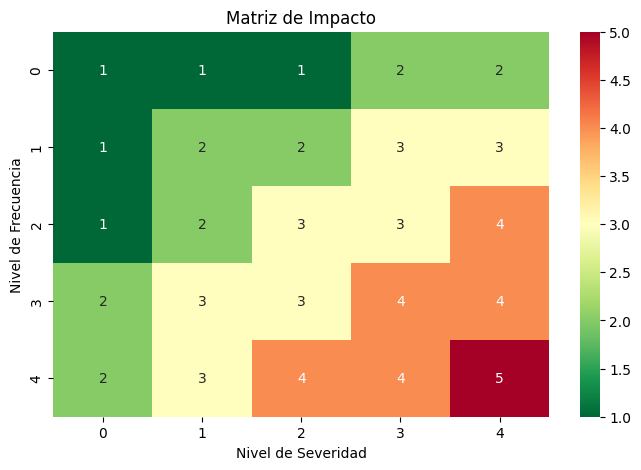

In [10]:
# Matriz de impacto

MI = np.array([[1,1,1,2,2],
               [1,2,2,3,3],
               [1,2,3,3,4],
               [2,3,3,4,4],
               [2,3,4,4,5]])

plt.figure(figsize=(8,5))
sns.heatmap(MI, annot=True, fmt='.0f', cmap='RdYlGn_r')
plt.title('Matriz de Impacto')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

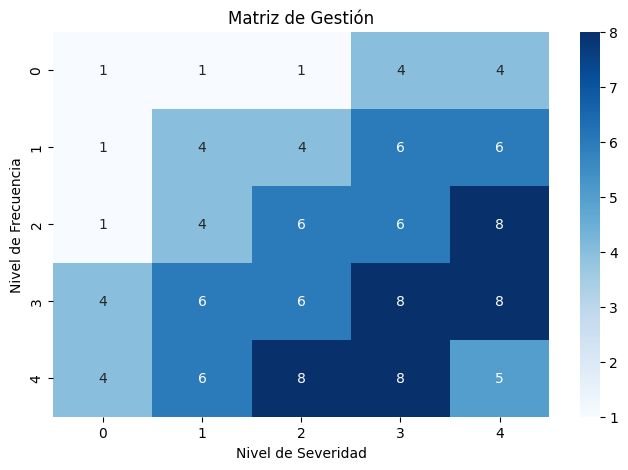

In [11]:
# Matriz de gestión

NG = 2   # 1, 2, 3 o 4

MG = np.copy(MI)

for i in range(5):
  for j in range(5):
    if MG[i,j] > 1 and MG[i,j] < 5:
      MG[i,j] = MG[i,j] * NG

plt.figure(figsize=(8,5))
sns.heatmap(MG, annot=True, fmt='.0f', cmap='Blues')
plt.title('Matriz de Gestión')
plt.xlabel('Nivel de Severidad')
plt.ylabel('Nivel de Frecuencia')
plt.show()

**5. Pérdida esperada**

In [12]:
# Pérdida esperada

PE_simple = np.mean(Xs)

PE_ponderada = np.sum(MEf * MEs) / np.sum(MEf)

PE_inherente = np.sum(MEf * MEs * MI) / np.sum(MEf * MI)

PE_residual = np.sum(MEf * MEs * MI) / np.sum(MEf * MG)

print("Pérdida esperada simple:", round(PE_simple, 4), "MM USD")
print("Pérdida esperada ponderada:", round(PE_ponderada, 4), "MM USD")
print("Pérdida esperada riesgo inherente:", round(PE_inherente, 4), "MM USD")
print("Pérdida esperada riesgo residual:", round(PE_residual, 4), "MM USD")

reduccion = (PE_inherente - PE_residual) / PE_inherente * 100
print("Reducción por gestión:", round(reduccion, 2), "%")

Pérdida esperada simple: 1.9296 MM USD
Pérdida esperada ponderada: 1.9963 MM USD
Pérdida esperada riesgo inherente: 2.5699 MM USD
Pérdida esperada riesgo residual: 1.3782 MM USD
Reducción por gestión: 46.37 %


**6. Operational Value at Risk (OpVaR) a un nivel de confianza del 99,9%**

In [13]:
# OpVaR al 99.9%

LDA_inherente = np.zeros(len(df))
LDA_residual = np.zeros(len(df))

for k in range(len(df)):
  nf = int(df.loc[k, 'Nivel_f'])
  ns = int(df.loc[k, 'Nivel_s'])

  LDA_inherente[k] = df.loc[k, 'Severidad'] * MI[nf, ns]
  LDA_residual[k] = df.loc[k, 'Severidad'] * MI[nf, ns] / MG[nf, ns]

OpVaR_inherente = np.percentile(LDA_inherente, 99.9)
OpVaR_residual = np.percentile(LDA_residual, 99.9)

print("OpVaR 99.9% riesgo inherente:", round(OpVaR_inherente, 4), "MM USD")
print("OpVaR 99.9% riesgo residual:", round(OpVaR_residual, 4), "MM USD")

reduccion_opvar = (OpVaR_inherente - OpVaR_residual) / OpVaR_inherente * 100
print("Reducción del OpVaR por gestión:", round(reduccion_opvar, 2), "%")

OpVaR 99.9% riesgo inherente: 54.0942 MM USD
OpVaR 99.9% riesgo residual: 10.8188 MM USD
Reducción del OpVaR por gestión: 80.0 %


**7. Comparación gráfica de las pérdidas no gestionadas y gestionadas**

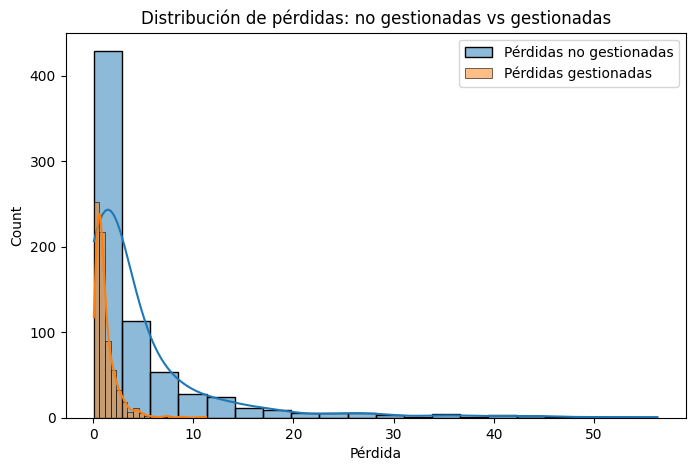

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(LDA_inherente, bins=20, kde=True, label='Pérdidas no gestionadas')
sns.histplot(LDA_residual, bins=20, kde=True, label='Pérdidas gestionadas')
plt.title('Distribución de pérdidas: no gestionadas vs gestionadas')
plt.xlabel('Pérdida')
plt.legend()
plt.show()

Se observa que la distribución del riesgo residual está más concentrada en valores bajos, lo que confirma que la gestión reduce la magnitud de las pérdidas.

**8. Filtro dinámico de auditoría**

In [26]:
# Filtro dinámico de auditoría

def auditoria(nivel_frecuencia, nivel_severidad):

  filtro = df[
      (df['Nivel_f'] == nivel_frecuencia) &
      (df['Nivel_s'] == nivel_severidad)
  ]

  print("====================================")
  print("ANÁLISIS DE CELDA")
  print("====================================")
  print(f"Nivel de frecuencia: {nivel_frecuencia}")
  print(f"Nivel de severidad: {nivel_severidad}")
  print(f"Número de eventos: {len(filtro)}")
  print(f"Pérdida total: {round(filtro['LDA'].sum(),4)} MM USD")
  print(f"Pérdida promedio: {round(filtro['LDA'].mean(),4)} MM USD")
  print("====================================")

  return filtro[['Fecha','Frecuencia','Severidad','LDA','Descripcion_Evento']]

In [27]:
# Ejemplo de uso del filtro
# Cambiar los números según la celda que se quiera revisar

auditoria(3, 4)

ANÁLISIS DE CELDA
Nivel de frecuencia: 3
Nivel de severidad: 4
Número de eventos: 8
Pérdida total: 653.2975 MM USD
Pérdida promedio: 81.6622 MM USD


,Fecha,Frecuencia,Severidad,LDA,Descripcion_Evento
7,2009-01-08,8,12.4245,99.3960,"Caída total del sistema por más de 24 horas, p..."
64,2009-03-06,9,6.6729,60.0561,Degradación severa del rendimiento por más de ...
250,2009-09-08,9,7.2127,64.9143,Degradación severa del rendimiento por más de ...
252,2009-09-10,10,11.1083,111.0830,"Caída total del sistema por más de 24 horas, p..."
298,2009-10-26,8,10.4570,83.6560,"Caída total del sistema por más de 24 horas, p..."
383,2011-02-03,9,9.0824,81.7416,Degradación severa del rendimiento por más de ...
410,2011-03-02,8,9.8843,79.0744,"Caída total del sistema por más de 24 horas, p..."
412,2011-03-04,9,8.1529,73.3761,Degradación severa del rendimiento por más de ...


### **Análisis de resultados**

**1. Base de datos**

La base contiene 701 registros de eventos asociados a fallas tecnológicas en canales electrónicos. Para el desarrollo del trabajo se utilizaron principalmente dos variables: la frecuencia del evento y la severidad económica de la falla. A partir de estas variables se construyeron las matrices de frecuencia, severidad, pérdidas agregadas, impacto y gestión.

El análisis permite observar que el riesgo operacional tecnológico no se explica únicamente por eventos extremos, sino también por fallas repetitivas que al acumularse pueden generar una pérdida importante para la entidad.

**2. Matriz de frecuencia y severidad**

La matriz de frecuencia permite identificar en qué combinaciones de niveles se concentran los eventos. En este caso, los eventos se clasificaron en cinco niveles, desde bajo hasta alto, usando la función de clusterización trabajada en clase.

La matriz de severidad muestra que hay diferencias importantes entre las celdas. Algunas combinaciones no necesariamente tienen la mayor cantidad de eventos, pero sí presentan valores altos de severidad. Esto es importante porque una celda con pocos eventos puede representar un riesgo relevante si sus pérdidas son elevadas.

**3. Matriz de pérdidas agregadas**

La matriz de pérdidas agregadas se obtuvo multiplicando la matriz de frecuencia por la matriz de severidad. El resultado total de pérdidas agregadas fue de 7247.4869 MM USD.

Este valor muestra la exposición total estimada al combinar la cantidad de eventos con su impacto económico. Por esta razón, la matriz de pérdidas agregadas es una herramienta útil para priorizar las zonas de mayor riesgo.

**4. Pérdida esperada**

La pérdida esperada simple fue de 4.0478 MM USD, mientras que la pérdida esperada ponderada fue de 2.175 MM USD. La diferencia entre estos valores se debe a que la pérdida ponderada tiene en cuenta la frecuencia de ocurrencia de los eventos.

Al incorporar la matriz de impacto, la pérdida esperada del riesgo inherente fue de 2.8118 MM USD. Después de aplicar la matriz de gestión con un nivel de gestión igual a 2, la pérdida esperada residual fue de 1.5079 MM USD.

Esto representa una reducción de 1.3039 MM USD, equivalente al 46.4%. Este resultado evidencia que los controles y actividades de gestión tienen un efecto importante en la disminución de la exposición económica.

**5. OpVaR al 99.9%**

El OpVaR al 99.9% para el riesgo inherente fue de 54.0942 MM USD, mientras que para el riesgo residual fue de 10.8188 MM USD.

La reducción del OpVaR fue de 43.2754 MM USD, lo cual muestra que la gestión del riesgo no solo reduce la pérdida promedio, sino también el posible impacto de eventos extremos. Este punto es importante porque en riesgo operacional los eventos de baja probabilidad pero alto impacto pueden afectar de forma significativa a la entidad.

**6. Herramienta de auditoría**

El filtro dinámico de auditoría permite seleccionar una celda específica de la matriz y revisar los eventos que la componen. Esto ayuda a pasar de un análisis general a una revisión más detallada, ya que permite observar la fecha, frecuencia, severidad, pérdida y descripción de cada evento.

Esta herramienta es útil para la toma de decisiones porque permite identificar qué eventos están generando mayor exposición y qué controles deberían revisarse o fortalecerse.

- Pérdida agregada total: 7247.4869 MM USD

- Pérdida esperada simple: 4.0478 MM USD

- Pérdida esperada ponderada: 2.175 MM USD

- PE riesgo inherente: 2.8118 MM USD

- PE riesgo residual: 1.5079 MM USD

- Reducción por gestión: 1.3039 MM USD

- Porcentaje de reducción: 46.4%

- OpVaR 99.9% inherente: 54.0942 MM USD

- OpVaR 99.9% residual: 10.8188 MM USD

- Reducción OpVaR: 43.2754 MM USD


### **Conclusiones**

A partir del análisis realizado, se concluye que las fallas tecnológicas en canales electrónicos representan un riesgo operacional relevante para la entidad, tanto por su frecuencia como por su severidad económica.

La pérdida agregada total fue de 7247.4869 MM USD, lo que evidencia que la acumulación de eventos tecnológicos puede generar una exposición importante. Aunque muchos eventos pueden parecer menores de forma individual, al analizarlos en conjunto tienen un impacto considerable.

La pérdida esperada del riesgo inherente fue de 2.8118 MM USD, mientras que la pérdida esperada residual fue de 1.5079 MM USD. Esto muestra que la gestión del riesgo permitió reducir la pérdida esperada en 46.4%, lo cual confirma la importancia de contar con controles, monitoreo y planes de respuesta ante fallas tecnológicas.

El OpVaR al 99.9% pasó de 54.0942 MM USD en el escenario inherente a 10.8188 MM USD en el escenario residual. Esta reducción de 43.2754 MM USD demuestra que los controles también ayudan a disminuir la exposición frente a eventos extremos.

Finalmente, la herramienta de auditoría complementa el análisis porque permite revisar los eventos específicos que forman cada celda de la matriz. Esto facilita identificar fallas críticas, analizar sus causas y priorizar acciones de mejora en los canales electrónicos.